# Time Series Forecasting - Team 8

In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display

# Pre-process Dataset

In [2]:
# Manually download dataset into /docs
# Check files/ File path
DOCS_PATH = "/content/docs"

print("Files in docs folder:", os.listdir(DOCS_PATH))

TRAIN_PATH = os.path.join(DOCS_PATH, "train.parquet")
TEST_PATH = os.path.join(DOCS_PATH, "test.parquet")

# Lazy load
train_df = pl.scan_parquet(TRAIN_PATH)
test_df = pl.scan_parquet(TEST_PATH)

# Print schema
print("Schema:")
print(test_df.schema)

# Get shape (forces minimal computation)
print("Train shape:", train_df.select(pl.count()).collect())
print("Test shape:", test_df.select(pl.count()).collect())
# Preview data (only loads small sample)
display(train_df.head(5).collect())
display(test_df.head(5).collect())

Files in docs folder: ['test.parquet', 'train.parquet']
Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Flo

/tmp/ipykernel_61282/1005924137.py:16: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(test_df.schema)
/tmp/ipykernel_61282/1005924137.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Train shape:", train_df.select(pl.count()).collect())
/tmp/ipykernel_61282/1005924137.py:20: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  print("Test shape:", test_df.select(pl.count()).collect())


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [3]:
train_df = (
    pl.scan_parquet(TRAIN_PATH)
    .sort(["code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

/tmp/ipykernel_61282/3781260164.py:6: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  train_df = train_df.collect(streaming=True)


In [4]:
num_cols = [col for col in train_df.columns if col not in ["code", "ts_index"]]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over("code")
    .alias(col)
    for col in num_cols
])

# Median imputation
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over("code"))
    .alias(col)
    for col in num_cols
])

Summary Statistics

In [5]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061604  ┆ 2.323426  ┆

Feature Distributions

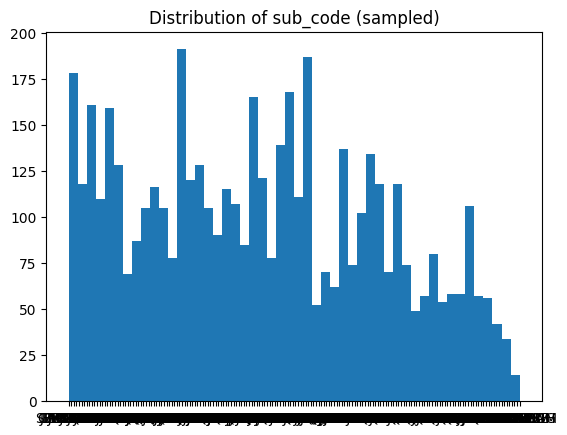

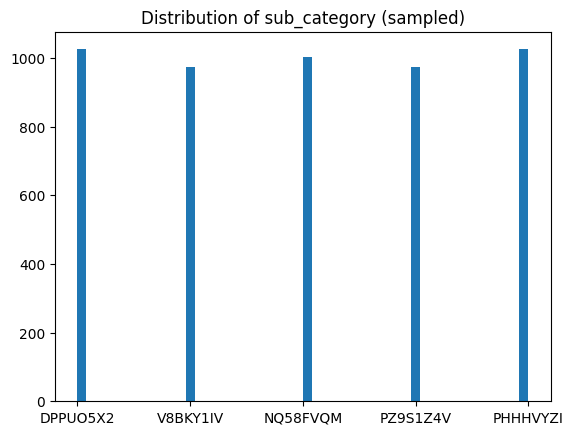

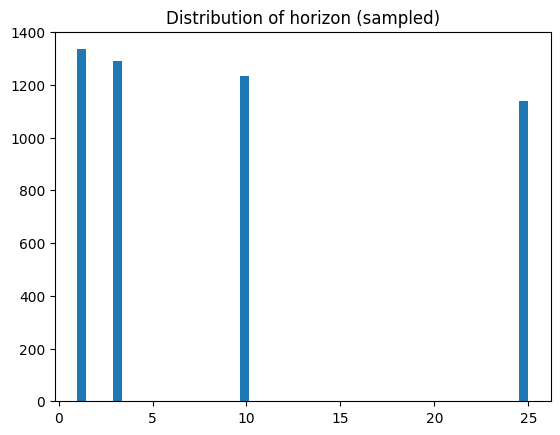

In [6]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()

Volatility Check

In [7]:
# Rolling Volatility
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_std(window_size=10)
    .over("code")
    .alias("y_volatility")
])

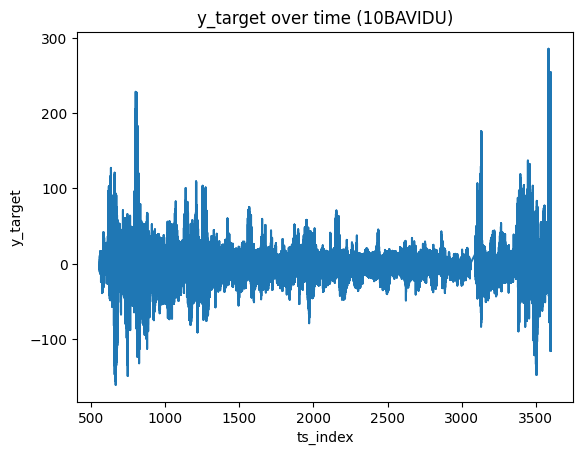

In [8]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [9]:
train_df = train_df.with_columns([
    pl.col("y_target")
    .rolling_mean(window_size=10)
    .over("code")
    .alias("y_rolling_mean")
])
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""660DZME0__916L3K5Q__NQ58FVQM__…","""660DZME0""","""916L3K5Q""","""NQ58FVQM""",1.0,2648,37.0,16.811266,6.857021,12.299781,3.112558,14.996563,12.359253,0.000411,0.000478,0.000014,0.000015,0.406321,0.146338,-0.913031,0.601179,0.300518,0.32571,8.267933,2.52459,2.082546,2.023707,63.759529,0.0,21.041562,93.591635,148.395201,0.971533,2.238193,1.441961,1.775285,8.382149,…,898.076409,8.335796,1.3760e6,763101.761364,777580.18533,0.009392,1.7349e6,0.130863,1661.456663,65898.746944,0.001305,409.440382,729.218122,746.003569,0.158342,0.006667,0.002889,-0.508863,-3.141712,-3.255671,0.088177,0.257933,0.431733,-0.083817,-0.028777,-0.053377,-2.032654,-0.075521,-1.347135,0.015771,0.138963,0.085733,0.0,-0.013881,150.315699,0.824305,1.074733
"""4KUR2ZOZ__II90M002__V8BKY1IV__…","""4KUR2ZOZ""","""II90M002""","""V8BKY1IV""",25.0,888,144.0,13.665077,1.600439,10.174566,9.649417,6.561539,9.823187,0.017009,0.025481,0.001683,0.00034,3.460622,0.057062,0.002433,0.002811,0.023622,0.002225,0.000588,0.150256,0.06193,0.064994,2.137657,0.536887,1.064568,54.725926,-172.337092,0.042495,0.717699,0.291499,0.097606,0.000757,…,602.659039,3865.318117,169941.137251,676375.498636,42898.460812,0.000734,940667.578063,0.154672,7666.223488,1151.041603,0.07549,13.423094,0.725956,18.740402,2.63645,0.11466,0.993373,-0.347775,-0.279283,-3.334333,2.712977,3.203741,6.580395,-0.17647,-0.028235,-0.000353,-0.000579,-0.02712,-0.000881,-0.47826,4.037369,0.047179,2.0,-0.14091,1154.575342,0.094262,0.022434
"""W4S29LF4__NSYBU89B__DPPUO5X2__…","""W4S29LF4""","""NSYBU89B""","""DPPUO5X2""",3.0,3057,50.0,4.502412,11.498188,13.778122,12.47275,3.054305,10.988939,0.020017,0.005115,0.000397,0.012418,2.10097,0.037093,-3.092739,11.52459,0.436571,0.992553,0.732735,16.964302,18.457095,449.127845,17.665924,38.399776,-8.944682,3.825539,2.341072,0.079421,0.026937,0.057623,0.022797,1.211052,…,7.906842,0.775162,482188.921775,833334.149565,36110.70908,0.217547,69925.433049,0.465432,84.745559,91.712405,0.000138,6300.966237,1815.418425,5641.414107,0.000322,0.000896,0.000284,-0.108974,-0.217571,-3.382064,0.174032,5.864662,5.04268,-0.247757,-2.602363,-0.152356,-0.229401,-0.27397,-10.418795,-0.043207,0.041518,0.500504,0.0,46.419141,0.020101,83.218289,28.050597
"""6LB028J8__916L3K5Q__PHHHVYZI__…","""6LB028J8""","""916L3K5Q""","""PHHHVYZI""",3.0,2641,46.0,12.794555,13.355231,4.590214,2.892972,11.208682,11.158779,0.001641,0.009161,0.002946,0.000124,0.222182,3.024773,-0.002762,0.000459,0.000691,0.000966,0.005865,0.256539,0.3265,0.012784,0.013061,14.02032,1.159698,127.311445,8.652818,0.104969,0.026026,0.006767,0.011995,0.006967,…,4210.910347,22096.820283,114888.690206,1.1140e6,1.2278e6,0.150808,2.1853e6,16.677267,759.209288,8330.853661,0.063964,3.582132,0.251141,6.154533,8.13593,9.361013,8.41223,-6.59212,-0.17587,-0.103136,0.138493,1.081711,11.058221,-0.000203,-0.00048,-0.012512,-0.014267,-0.016999,-0.000457,0.005416,0.13855,1.558796,2.0,0.105289,9407.109364,0.0627

In [10]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)

shape: (1, 10)
┌─────┬──────────┬──────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ id  ┆ sub_code ┆ sub_category ┆ horizon   ┆ … ┆ feature_c ┆ feature_d ┆ feature_e ┆ feature_f │
│ --- ┆ ---      ┆ ---          ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│ f64 ┆ f64      ┆ f64          ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
╞═════╪══════════╪══════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ NaN ┆ NaN      ┆ NaN          ┆ -0.018719 ┆ … ┆ 0.00057   ┆ 0.000097  ┆ -0.000574 ┆ -0.000027 │
└─────┴──────────┴──────────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


# Baseline Model

First, the necessary libraries and modules are imported for the creation of this base model, which includes using HistGradientBoostingRegressor.

In [11]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 96)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight,y_volatility,y_rolling_mean
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",3.0,3531,141.0,3.475385,15.13462,3.265031,10.380979,8.83843,2.01938,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,0.670754,0.017167,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,5.601772,0.010329,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",25.0,3531,119.0,11.262484,1.45387,6.210146,8.292425,1.175443,15.234003,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,8.425576,0.016712,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3531,143.0,2.296699,1.939771,15.459024,8.540194,16.673829,14.100175,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.002724,0.073858,0.046283,2.0,-2.795824,0.032189,null,null
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",1.0,3532,142.0,4.631196,2.84

Next, we define the dataset with focus on features, weight and target.

In [12]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"

SAMPLE_FRAC = 0.1

train_df = (
    train_df
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [13]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))

def compute_weights(df):

    return np.ones(len(df))

Time-series validation splits are then defined to prevent data leakage.

---



In [14]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

splits = list(tscv.split(X))

print(f"Number of splits: {len(splits)}")

Number of splits: 5


Most importantly, we train the baseline model. We are using the tree based model, HistGradientBoostingRegressor.

In [15]:
def train_baseline_hgbr(X, y, w, splits):

    X_np = np.asarray(X)
    y_np = np.asarray(y).flatten()
    w_np = np.asarray(w).flatten()

    oof_predictions = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #scaling
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        #model
        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.11,
            max_depth=6,
            min_samples_leaf=20,
            l2_regularization=0.5,
            max_bins=255,
            validation_fraction=0.5,
            n_iter_no_change=60,
            random_state=SEED
        )

        model.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = model.predict(X_val)
        preds = preds_scaled * y_std + y_mean

        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_predictions[val_idx] = preds

    return oof_predictions

Now we display the score and dataset stats produced by the trained model

In [16]:
oof_preds = train_baseline_hgbr(X, y, w, splits)
train_weights = compute_weights(train_df)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

print(f"OOF Score: {oof_score:.5f}")
print("----------------------------")
y_true = train_df[TARGET].to_numpy()

print("OOF mean:", oof_preds.mean())
print("y_true mean:", y_true.mean())
print("OOF min/max:", oof_preds.min(), oof_preds.max())
print("y_true min/max:", y_true.min(), y_true.max())
print("X shape:", X.shape)
print("Number of splits:", len(splits))

OOF Score: 0.09147
----------------------------
OOF mean: -0.5366845753029574
y_true mean: -0.6660210131631762
OOF min/max: -86.10088142965665 20.338573067022253
y_true min/max: -1351.8651089498348 2125.2380157082684
X shape: (533741, 86)
Number of splits: 5


Adding compute functions - feature experiment validation support.

In [17]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

Use rmse and mae to compute fold metrics - feature experiment validation support.

In [18]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        # Calculate MSE and then take the square root for RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Display the folds using rmse and mae - feature experiment validation support.

In [19]:
oof_preds = train_baseline_hgbr(X, y, w, splits)

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

print("Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"\nMean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")

Fold-wise scores:
Fold 1 - RMSE: 22.7354, MAE: 4.0637
Fold 2 - RMSE: 32.6094, MAE: 5.3125
Fold 3 - RMSE: 37.9873, MAE: 7.1747
Fold 4 - RMSE: 27.8710, MAE: 5.8335
Fold 5 - RMSE: 28.6255, MAE: 6.6272

Mean RMSE: 29.9657, Mean MAE: 5.8023


Next, we evaluate the model using competition metric.
We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [20]:
test_df_processed = (
    pl.scan_parquet(TEST_PATH)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

#Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

#Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

#Rolling Volatility
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_std(window_size=10)
      .over(CODE)
      .alias("y_volatility")
  ])

#Rolling Mean
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_mean(window_size=10)
      .over(CODE)
      .alias("y_rolling_mean")
  ])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25.0,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1.0,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10.0,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4176,207.0,14.844531,1.652745,3.959252,4


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Float64, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float6

Secondly, we must select our features for testing and preview the test.

In [21]:
X_test = test_df_processed.select(FEATURES)

print("\nX_test Head:")
display(X_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871

Finally, we must train the sample data for testing to obtain predictions and construct a submission

In [22]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)

final_model.fit(X.to_numpy(), y.to_numpy().flatten())

print("\nMaking predictions on test data...")

test_preds = final_model.predict(X_test.to_numpy())

submission = test_df_processed.select(["id"]).with_columns(
    pl.Series("prediction", test_preds)
)

print(submission)

Training final model on sampled training data...

Making predictions on test data...
shape: (1_447_107, 2)
┌─────────────────────────────────┬────────────┐
│ id                              ┆ prediction │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.330158   │
│ …                               ┆ …          │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
└─────────────────────────────────┴────────────┘


To conclude with model building, we display the key results in a table.

In [23]:
import pandas as pd
import numpy as np

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

results_table = pd.DataFrame({
    "model": ["HistGradientBoosting_Baseline"],
    "mean_cv_score": [np.mean([fs["rmse"] for fs in fold_scores])],
    "std_cv_score": [np.std([fs["rmse"] for fs in fold_scores])],
    "final_test_score": [oof_score]
})

print(results_table.to_string(index=False))

                        model  mean_cv_score  std_cv_score  final_test_score
HistGradientBoosting_Baseline      29.965706      5.095024          0.091472


# Feature Engineering

### Horizon Based Features

In [33]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

X_base = X.clone()
X_base = X_base.with_columns(train_df["horizon"].alias("horizon"))

y_base = "y_target"
y_base = train_df.select(y_base)

def create_horizon_features(X):
    X_new = X.clone()

    # safer grouping
    X_new = X_new.with_columns(
        pl.when(pl.col("horizon") <= 3).then(0)
        .when(pl.col("horizon") <= 10).then(1)
        .otherwise(2)
        .alias("horizon_group")
    )

    # only selected interactions
    important_cols = [
        "feature_v",
        "feature_bz",
        "feature_al",
        "feature_bp",
        "feature_bm"
    ]

    for col in important_cols:
        if col in X_new.columns:
            X_new = X_new.with_columns(
                (pl.col(col) * pl.col("horizon"))
                .alias(f"{col}_x_horizon")
            )

    return X_new


In [34]:
X_horizon = create_horizon_features(X_base)

print("Original shape:", X_base.shape)
print("New shape:", X_horizon.shape)

def train_model(X, y, w, splits, model):

    X_np = X.to_numpy()
    y_np = y.to_numpy().flatten()
    w_np = w.to_numpy().flatten()

    oof_preds = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        # Target scaling logic from baseline
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        m = clone(model)
        # Apply weights during training
        m.fit(X_train, y_train_scaled, sample_weight=w_train)

        # Inverse transform predictions and clip
        preds_scaled = m.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_preds[val_idx] = preds

    return oof_preds

Original shape: (533741, 87)
New shape: (533741, 93)


In [35]:
oof_horizon_score = train_model(
    X_horizon,
    y_base,
    w,
    splits,
    final_model,
)

import numpy as np

# Evaluate Horizon model using the same weighted RMSE metric as baseline
# Note: We must exclude the first 88961 samples because they are never predicted in TimeSeriesSplit
valid_indices = np.concatenate([
    val_idx for _, val_idx in splits
])

valid_mask = np.zeros(len(oof_horizon_score), dtype=bool)
valid_mask[valid_indices] = True

horizon_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_horizon_score[valid_mask],
    train_weights[valid_mask]
)

baseline_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_preds[valid_mask],
    train_weights[valid_mask]
)

print(f"Baseline Weighted RMSE: {baseline_weighted_score:.5f}")
print(f"Horizon Weighted RMSE:  {horizon_weighted_score:.5f}")
print(f"Improvement: {baseline_weighted_score - horizon_weighted_score:.5f}")

import numpy as np

# 1. Check how many zeros are in the OOF predictions
num_zeros = np.sum(oof_horizon_score == 0)
total = len(oof_horizon_score)
print(f"Number of zero predictions: {num_zeros} out of {total} ({num_zeros/total:.2%})")

# 2. Check the split indices to see if early indices are ever used in validation
print("\nValidation indices per split:")
for i, (train_idx, val_idx) in enumerate(splits):
    print(f"Fold {i+1}: Val Start={val_idx[0]}, Val End={val_idx[-1]}")

# 3. Check the target distribution to see if the clipping value is zero
print(f"\ny_target min: {y_base.to_numpy().min()}")

Baseline Weighted RMSE: 0.10587
Horizon Weighted RMSE:  0.05624
Improvement: 0.04962
Number of zero predictions: 88961 out of 533741 (16.67%)

Validation indices per split:
Fold 1: Val Start=88961, Val End=177916
Fold 2: Val Start=177917, Val End=266872
Fold 3: Val Start=266873, Val End=355828
Fold 4: Val Start=355829, Val End=444784
Fold 5: Val Start=444785, Val End=533740

y_target min: -1351.8651089498348


In [36]:
print("Baseline Score:", np.mean(oof_score))
print("Horizon Score:", np.mean(oof_horizon_score))

improvement = (
    np.mean(oof_horizon_score) - np.mean(oof_score)
)

print("Average Improvement:", improvement)

Baseline Score: 0.0914719406155144
Horizon Score: -0.2737671192084496
Average Improvement: -0.365239059823964


In [37]:
print(np.corrcoef(
    train_df["horizon"].to_numpy(),
    train_df[TARGET].to_numpy()
)[0,1])

-0.01872316665869113


### Feature Selection

In [30]:
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# =====================================
# Validation Splits
# =====================================
def time_splits(n):
    fold_size = n // (N_SPLITS + 1)

    splits = []
    for i in range(1, N_SPLITS + 1):
        train_end = i * fold_size
        val_end = (i + 1) * fold_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        splits.append((train_idx, val_idx))
    return splits

# =====================================
# Computing Temporal Feature Importance
# =====================================
def compute_temporal_importance(df, target, n_repeats=5):
    feature_df = df.select(
        pl.col("^feature.*$"),
        target
    )

    X = feature_df.drop(target)
    y = feature_df.select(target).to_numpy().ravel()

    X_np = X.to_numpy()
    feature_names = X.columns

    splits = time_splits(len(X_np))

    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"Processing fold {fold+1}")

        X_train = X_np[train_idx]
        y_train = y[train_idx]

        X_val = X_np[val_idx]
        y_val = y[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        perm = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=n_repeats,
            random_state=SEED,
            n_jobs=-1
        )

        all_importances.append(perm.importances_mean)

    importances_array = np.array(all_importances)

    mean_importance = importances_array.mean(axis=0)
    std_importance = importances_array.std(axis=0)

    stability_score = mean_importance / (std_importance + 1e-6)

    feature_importance_df = pl.DataFrame({
        "feature": feature_names,
        "mean_importance": mean_importance,
        "std_importance": std_importance,
        "stability_score": stability_score
    }).sort("mean_importance", descending=True)

    return feature_importance_df

# =====================================
# Selecting Features (based on stability + importance)
# =====================================
def select_features(
    feature_importance_df,
    unstable_threshold,
    stability_floor=0.5
):
    # Stable
    stable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > 0) &
            (pl.col("stability_score") > 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    # Unstable but useful
    unstable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > unstable_threshold) &
            (pl.col("stability_score") > stability_floor) &
            (pl.col("stability_score") <= 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    final_features = list(dict.fromkeys(
        stable_features + unstable_features
    ))

    print(f"Stable: {len(stable_features)}")
    print(f"Unstable added: {len(unstable_features)}")
    print(f"Final total: {len(final_features)}")
    print(f"Final Features: {final_features}")

    return final_features

In [31]:
'''
# compute importance
importance_df = compute_temporal_importance(train_df, TARGET)

# inspect and select thresholds
print(importance_df.select("mean_importance").describe())

threshold = 0.01

# select features
final_features = select_features(
    importance_df,
    unstable_threshold=threshold
)
'''

'\n# compute importance\nimportance_df = compute_temporal_importance(train_df, TARGET)\n\n# inspect and select thresholds\nprint(importance_df.select("mean_importance").describe())\n\nthreshold = 0.01\n\n# select features\nfinal_features = select_features(\n    importance_df,\n    unstable_threshold=threshold\n)\n'

### Lag Features

In [32]:
# Generate lag features
def generate_lags_polars(df, feature_cols, lag_list, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
        for lag in lag_list:
            # shift and fill nulls with 0
            lag_exprs.append(
                pl.col(col)
                .shift(lag)
                .over(group_col)
                .fill_null(0)
                .alias(f"{col}_lag_{lag}")
            )
    return df.with_columns(lag_exprs)

# Lag sets to evaluate
lag_sets = [
    [1],
    [1, 2],
    [1, 2, 3],
    [1, 2, 3, 5],
    [1, 2, 3, 5, 10],
    [1, 2, 3, 5, 10, 25]
]

results = []

for lags in lag_sets:
    print(f"\n==== Testing lags: {lags} ====")

    # Generate lag features
    df_lagged = generate_lags_polars(train_df, FEATURES, lags)

    # Select original + lag features
    lag_cols = [f"{col}_lag_{lag}" for col in FEATURES for lag in lags]
    lag_features = [c for c in df_lagged.columns if c in FEATURES or c in lag_cols]

    x_lag = df_lagged.select(lag_features)
    y_lag = df_lagged.select(TARGET)

    # Prepare time series splits
    splits_lag = list(TimeSeriesSplit(n_splits=N_SPLITS).split(x_lag))

    # Train baseline HGBR model
    oof_preds, fold_weighted_rmse = train_baseline_hgbr(x_lag, y_lag, splits_lag)

    # Compute fold-wise metrics
    fold_metrics, mean_rmse, mean_mae = compute_fold_metrics(
        y_lag.to_numpy().flatten(),
        oof_preds.flatten(),
        splits_lag
    )

    results.append({
        "lags": lags,
        "weighted_rmse": np.mean(fold_weighted_rmse),
        "rmse": mean_rmse,
        "mae": mean_mae,
        "fold_metrics": fold_metrics
    })

# Print results
results_df = pd.DataFrame(results)
print("\n=== Lag Feature Evaluation ===")
for res in results:
    print(f"\nLags tested: {res['lags']}")
    for f in res['fold_metrics']:
        print(f"  Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
    print(f"  Mean RMSE: {res['rmse']:.4f}, Mean MAE: {res['mae']:.4f}")


==== Testing lags: [1] ====


TypeError: train_baseline_hgbr() missing 1 required positional argument: 'splits'

In [ ]:
# Baseline metrics
baseline_rmse = 8.1374
baseline_mae = 6.6317

# Convert lag sets to a representative number (max lag in each set)
max_lags = [max(l) for l in results_df['lags']]

# Metrics
rmse = results_df['rmse']
mae = results_df['mae']

plt.figure(figsize=(8,5))

plt.plot(max_lags, rmse, marker='o', label='Lagged RMSE')
plt.plot(max_lags, mae, marker='o', label='Lagged MAE')
plt.axhline(baseline_rmse, color='blue', linestyle='--', label='Baseline RMSE')
plt.axhline(baseline_mae, color='orange', linestyle='--', label='Baseline MAE')

plt.xlabel('Max Lag in Set')
plt.ylabel('Metric Value')
plt.title('Effect of Lagged Features VS Baseline HGBR')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ts_index = df_lagged.select(TS_INDEX).to_numpy().flatten()
y_actual = y_lag.to_numpy().flatten()
y_pred = oof_preds.flatten()

start_idx = 2500
end_idx = 3500

mask = (ts_index >= start_idx) & (ts_index <= end_idx)

ts_zoom = ts_index[mask]
actual_zoom = y_actual[mask]
pred_lagged_zoom = y_pred[mask]
pred_actual_zoom = y_actual[mask]

plt.figure(figsize=(14,5))
plt.plot(ts_zoom, actual_zoom, label='Actual', color='blue')
plt.plot(ts_zoom, pred_lagged_zoom, label='Lagged Predicted', color='orange', alpha=0.7)
plt.xlabel('Time Index')
plt.ylabel('Target Value')
plt.title(f'Predicted vs Actual Values (ts_index {start_idx}-{end_idx})')
plt.legend()
plt.grid(True)
plt.show()